In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

merged = pd.read_csv("merged_data.csv")

In [ ]:
merged.head()

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),Batch_ID,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,0,NaN,0,0,1,1,1066400.0,1720000.0,2786400.0,0
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,0,4.083,0,0,1,1,1066400.0,1720000.0,2786400.0,0


In [ ]:
merged.shape

(113935, 39)

In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113935 entries, 0 to 113934
Data columns (total 39 columns):
 #   Column                                                              Non-Null Count   Dtype  
---  ------                                                              --------------   -----  
 0   Time (h)                                                            113935 non-null  float64
 1   Aeration rate(Fg:L/h)                                               113935 non-null  int64  
 2   Agitator RPM(RPM:RPM)                                               113935 non-null  int64  
 3   Sugar feed rate(Fs:L/h)                                             113935 non-null  int64  
 4   Acid flow rate(Fa:L/h)                                              113935 non-null  float64
 5   Base flow rate(Fb:L/h)                                              113935 non-null  float64
 6   Heating/cooling water flow rate(Fc:L/h)                             113935 non-null  float64
 7   He

In [ ]:
merged.describe()

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),Batch_ID,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
count,113935.000000,113935.000000,113935.0,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,...,113935.0,2062.000000,113935.000000,113935.000000,113935.000000,113935.000000,1.139350e+05,1.139350e+05,1.139350e+05,113935.000000
mean,114.750656,65.246360,100.0,76.663764,0.073209,61.334389,74.346341,20.763025,154.811954,0.945026,...,0.0,51.546454,0.011024,0.301795,50.402466,50.402466,1.107013e+06,1.912159e+06,3.019180e+06,0.101154
std,66.990504,11.690215,0.0,25.680134,0.552788,44.972713,108.022600,50.230266,155.601474,0.134269,...,0.0,24.073778,0.104415,0.459039,28.862140,28.862140,2.668860e+05,5.825535e+05,7.509214e+05,0.301534
min,0.200000,20.000000,100.0,2.000000,0.000000,0.000000,0.000100,0.000100,0.000000,0.600000,...,0.0,4.075300,0.000000,0.000000,1.000000,1.000000,3.886500e+05,5.021800e+05,8.908300e+05,0.000000
25%,57.000000,60.000000,100.0,72.000000,0.000000,35.766000,11.157000,0.000100,0.000000,0.900000,...,0.0,34.812250,0.000000,0.000000,26.000000,26.000000,9.680200e+05,1.383100e+06,2.426300e+06,0.000000
50%,114.000000,65.000000,100.0,80.000000,0.000000,55.407000,34.384000,0.159010,100.000000,0.900000,...,0.0,53.154000,0.000000,0.000000,50.000000,50.000000,1.095100e+06,2.089700e+06,3.099500e+06,0.000000
75%,171.000000,75.000000,100.0,90.000000,0.000000,76.271500,94.904500,11.640500,250.000000,1.100000,...,0.0,73.536000,0.000000,1.000000,76.000000,76.000000,1.198300e+06,2.373400e+06,3.588600e+06,0.000000
max,290.000000,75.000000,100.0,150.000000,12.996000,225.000000,1500.000000,1500.000000,500.000000,1.100000,...,0.0,117.930000,1.000000,1.000000,100.000000,100.000000,2.089700e+06,2.932400e+06,4.447700e+06,1.000000


In [ ]:
missing = merged.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
PAA concentration offline(PAA_offline:PAA (g L^{-1})),111873
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1})),111873
Offline Penicillin concentration(P_offline:P(g L^{-1})),111873
Offline Biomass concentratio(X_offline:X(g L^{-1})),111873
Viscosity(Viscosity_offline:centPoise),111873


In [ ]:
merged.duplicated().sum()

np.int64(0)

In [ ]:
merged.select_dtypes(include=np.number).columns

Index(['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)',
       'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)',
       'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)',
       'Heating water flow rate(Fh:L/h)',
       'Water for injection/dilution(Fw:L/h)',
       'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)',
       'Substrate concentration(S:g/L)',
       'Dissolved oxygen concentration(DO2:mg/L)',
       'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)',
       'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)',
       'Generated heat(Q:kJ)',
       'carbon dioxide percent in off-gas(CO2outgas:%)',
       'PAA flow(Fpaa:PAA flow (L/h))',
       'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
       'Oil flow(Foil:L/hr)',
       'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
       'Oxygen Uptake Rate(OUR:(g min^{-1}))',
       'Oxygen in percent in off-gas(O2:O2  (%))',
       'Offline Penicil

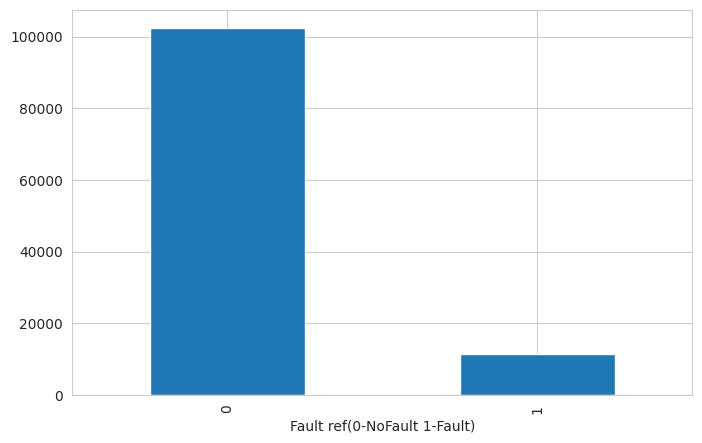

In [ ]:
#결측치 비율
merged["Fault ref(0-NoFault 1-Fault)"].value_counts().plot(kind="bar")
plt.show()

정상(0) 데이터가 대부분이며, Fault(1)는 약 10% 수준이다.

데이터가 불균형(Class Imbalance) 상태이므로 Fault 예측 모델을 만들 경우 Accuracy만으로 평가하기 어렵고 Precision, Recall, F1-score 등의 지표를 함께 고려해야 한다

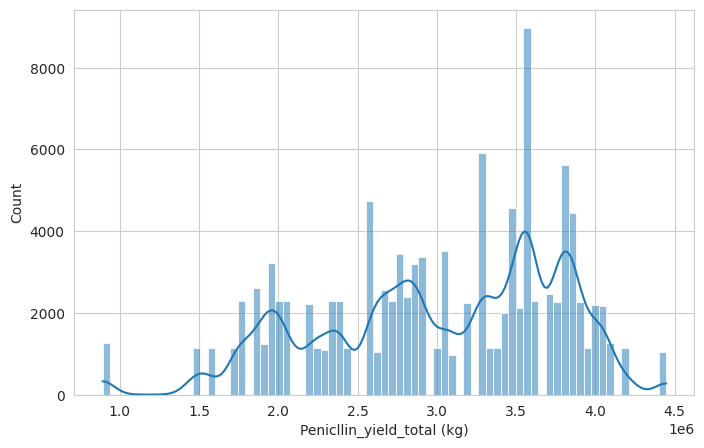

In [ ]:
#생산량 분포
sns.histplot(
    merged["Penicllin_yield_total (kg)"],
    kde=True
)
plt.show()

Penicillin 총 생산량은 약 0.9 ~ 4.5(×10⁶ kg) 범위에서 분포한다.

3.0~3.8 구간에 데이터가 가장 많이 분포하여 중간~높은 생산량의 배치가 많다.

분포가 완전한 정규분포는 아니며, 여러 개의 봉우리가 나타나는 다봉형(Multimodal) 분포를 보인다.

=>서로 다른 배치 조건이나 운전 조건의 영향을 받았을 가능성을 시사한다.

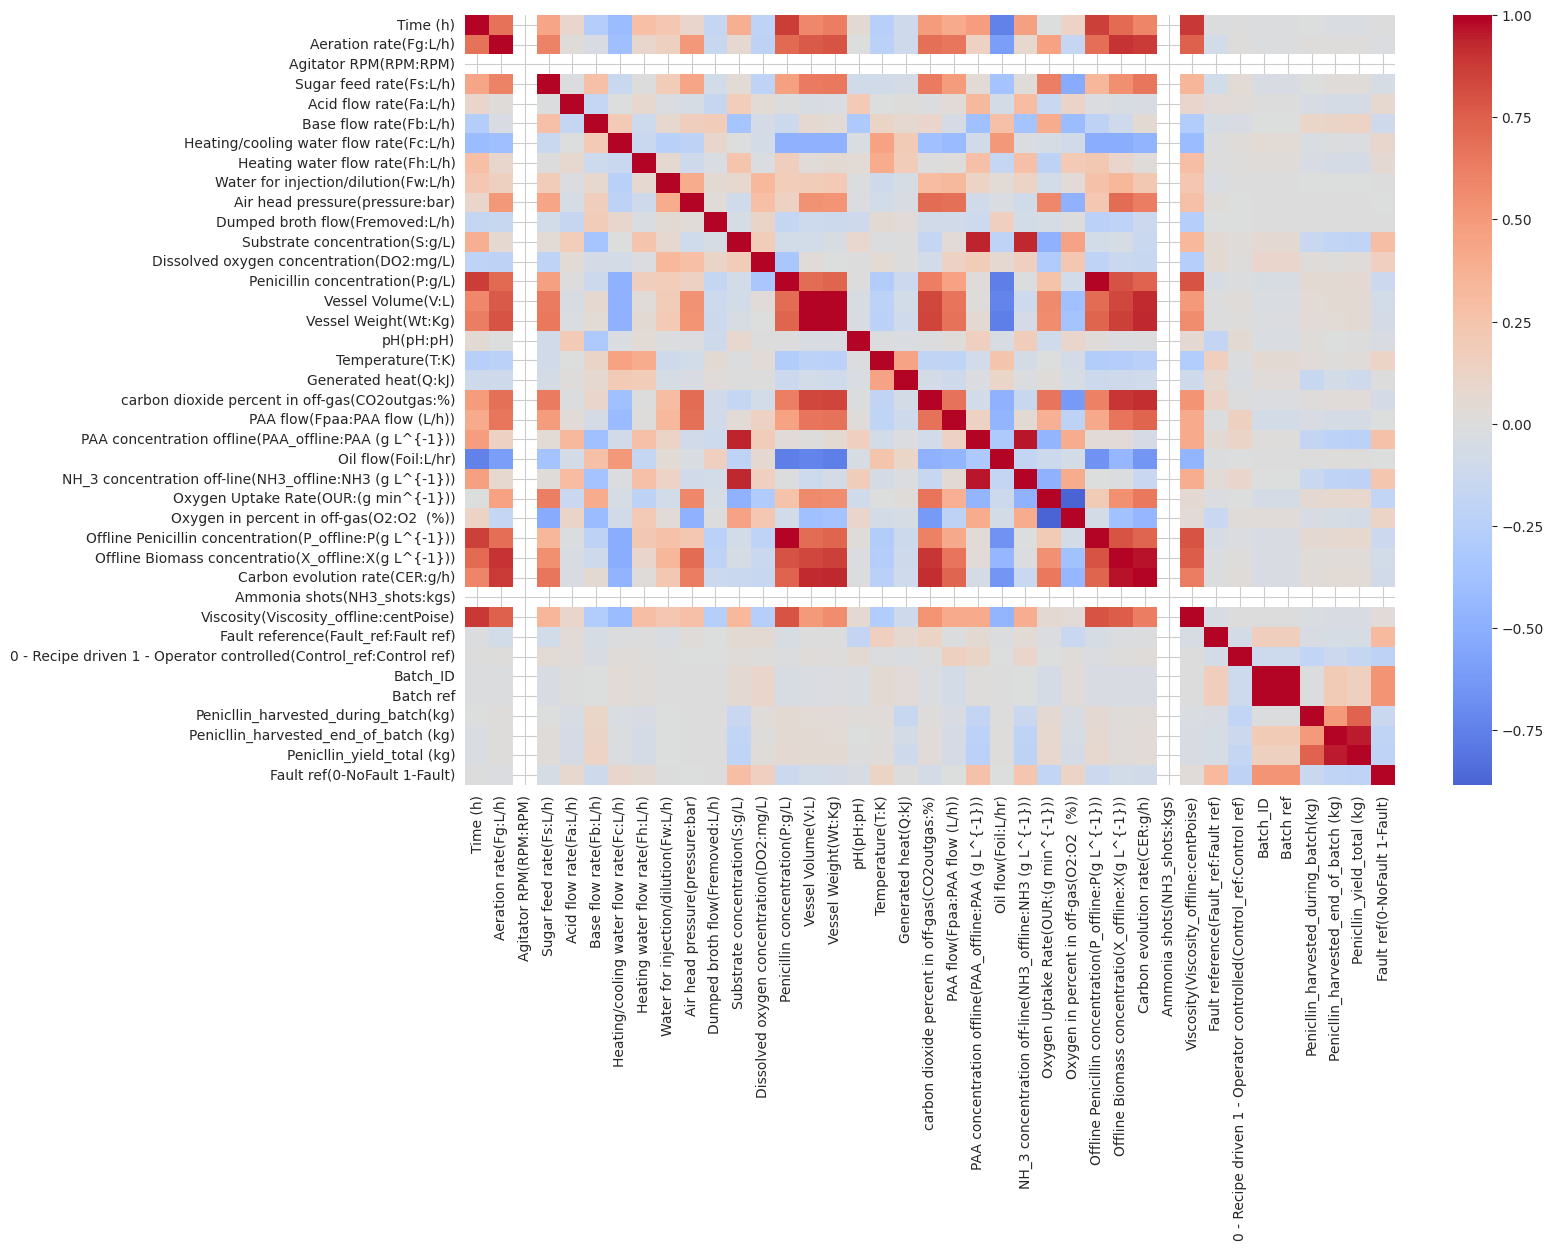

In [ ]:
#변수 간 상관관계
plt.figure(figsize=(15,10))
sns.heatmap(
    merged.corr(),
    cmap="coolwarm",
    center=0
)
plt.show()

Vessel Volume ↔ Vessel Weight


매우 높은 양의 상관관계

배양액의 양이 증가하면 무게도 함께 증가하는 자연스러운 결과이다.


---



Penicillin concentration ↔ Offline Penicillin concentration

높은 양의 상관관계

온라인 측정값과 오프라인 측정값이 유사한 경향을 보인다.



---


Offline Biomass ↔ Penicillin concentration

비교적 높은 양의 상관관계

균체량이 증가할수록 Penicillin 농도도 증가하는 경향이 있다.

대부분의 공정 변수는 강한 상관관계를 보이지 않아 여러 공정 변수의 복합적인 영향으로 생산량이 결정되는 것으로 해석할 수 있다.

<Axes: xlabel='Penicllin_yield_total (kg)'>

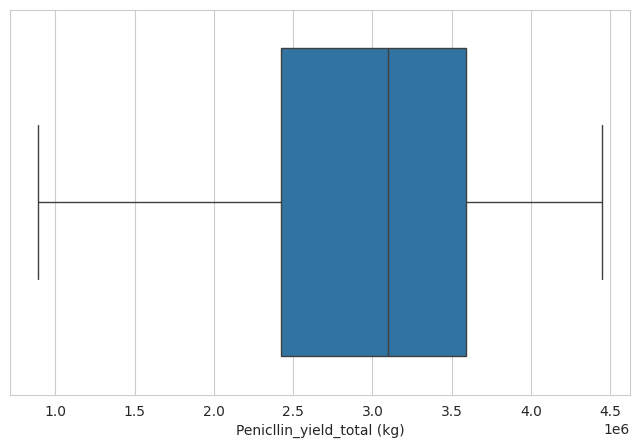

In [ ]:
#이상치 확인
sns.boxplot(
    x=merged["Penicllin_yield_total (kg)"]
)

중앙값은 약 3.1×10⁶ kg 수준이다.

사분위 범위(IQR)는 약 2.4~3.6×10⁶ kg이다.

극단적인 이상치가 거의 나타나지 않아 데이터 품질이 비교적 안정적이다.

생산량은 대부분 일정한 범위 내에서 관리되고 있음을 확인할 수 있다.

<최종 EDA>

데이터는 총 113,935개 관측치와 39개 변수로 구성되어 있다.

오프라인 측정 변수(PAA, NH₃, Biomass, Penicillin, Viscosity)는 특정 시점에서만 측정되어 결측치가 많다.

Penicillin 총 생산량은 3.0~3.8×10⁶ kg 구간에 집중되어 있으며 다봉형 분포를 보인다.

Fault 데이터는 약 **10%**로 정상 데이터에 비해 적어 클래스 불균형 특성을 가진다.

상관관계 분석 결과 일부 변수(Vessel Volume–Weight, Penicillin 농도 관련 변수)는 높은 상관관계를 보였으나, 대부분의 공정 변수는 단일 변수보다 복합적인 상호작용이 생산량에 영향을 미치는 것으로 해석된다.

Boxplot 분석에서는 뚜렷한 극단 이상치가 관찰되지 않아 데이터의 전반적인 품질이 양호한 것으로 확인되었다.

1.Penicillin 발효 공정 생산량 예측 및 핵심 공정 변수 분석

EDA 결과, Penicillin 생산량은 일정 범위에 집중되어 있으나 배치별 편차가 크게 나타났으며, 히스토그램에서 다봉형 분포를 보여 공정 조건에 따라 생산량이 달라질 가능성을 확인
 또한 상관관계 분석 결과 일부 공정 변수와 생산 관련 변수 간 높은 상관관계가 나타났지만, 대부분의 변수는 단일 변수보다 여러 공정 변수의 복합적인 영향을 받는 것으로 분석

 =>공정 데이터를 활용하여 최종 Penicillin 생산량을 예측

생산량에 영향을 미치는 핵심 공정 변수 도출

생산성 향상을 위한 공정 최적화 방안 제시

2.Penicillin 발효 공정 데이터 기반 생산량 영향 요인 분석 및 공정 최적화

EDA 결과, 공정 변수 간 일부 높은 상관관계가 확인되었으며, 생산량 역시 배치별 차이가 크게 나타났다. 특히 생산량 분포가 다봉형 형태를 보여 서로 다른 공정 조건이 생산성에 영향을 미칠 가능성이 확인되었다.

EDA를 통해 생산량의 분포와 공정 변수 간의 관계를 확인한 만큼, 어떤 공정 조건이 높은 생산량을 유도하는지 분석하는 것이 자연스러운 후속 연구가 될 수 있다

=>생산량과 공정 변수 간의 관계 분석

생산량에 영향을 미치는 핵심 공정 변수 선정

공정 조건별 생산성 비교

최적 공정 운영 방안 제시